### Data Extraction using Beautiful Soup

- Pricing Plans  (e.g., Free, Basic, Pro, Enterprise)
- Key Features

Website - https://www.salesforce.com/crm/pricing/


In [2]:
import requests
from bs4 import BeautifulSoup
import smtplib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# Function to extract information from any website (link as input)

URL = 'https://www.salesforce.com/sales/pricing/'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    "Referer": "https://www.google.com"
}

page = requests.get(URL, headers= headers)
soup = BeautifulSoup(page.content, 'html.parser')

In [91]:
articles = soup.find_all('article', {'data-module-type': 'card_pricingedition'})

pricing_data = []

for article in articles:
    plan_name = article.find('h3', class_='card__headline').text.strip()
    
    price_wrapper = article.find('div', class_ = 'card__price_wrapper default')

    plan_price = price_wrapper.find('span', class_ ='').text.strip()
    currency = price_wrapper.find('span', class_ = 'price_text__symbol').text
    unit= price_wrapper.find('div', class_ ='card__price_suffix').text.strip()

    pricing_data.append({
        'Plan':plan_name,
        'Price': plan_price,
        'Currency':currency,
        'Unit':unit
    })

pricing_data = pd.DataFrame(pricing_data).drop_duplicates()
pricing_data

,Plan,Price,Currency,Unit
0,Enterprise,165,$,USD/User/Month
1,Unlimited,330,$,USD/User/Month
2,Einstein 1 Sales,500,$,USD/User/Month
3,Starter Suite,25,$,USD/User/Month
4,Pro Suite,100,$,USD/User/Month


In [12]:
headers = soup.find_all('tbody', role = 'rowgroup')
feature_name = []
for header in headers:

    wrapper = header.find_all('tr', role = 'row')

    for feature in wrapper:
        
        feature_name.append(feature.find('p', class_='table_row_heading').text.strip())

feature_name = pd.DataFrame(feature_name)
feature_name.rename(columns = {0:'Features'}, inplace = True)
feature_name

,Features
0,"Account, Contact, Lead, and Opportunity Manage..."
1,Advanced Forecast & Pipeline Management
2,Sales Engagement & Conversation Intelligence*
3,Premier Success Plan
4,Agentforce*
...,...
76,Full Sandbox
77,Lightning Platform
78,Email Integration with Gmail or Outlook
79,Web Services API


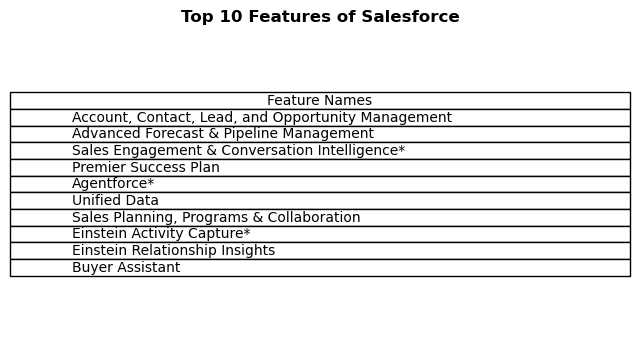

In [78]:
# Extract the first 10 features
top_10_features = feature_name.iloc[:10, 0].to_frame()
top_10_features.columns = ["Feature Names"]

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("tight")
ax.axis("off")

# Create a table
sns.despine(left=True, bottom=True)
table = ax.table(cellText=top_10_features.values, colLabels=top_10_features.columns, cellLoc="left", loc="center")

plt.title("Top 10 Features of Salesforce", fontsize=12, fontweight="bold")
plt.show()



In [97]:
pricing_data.to_csv("salesforce_data_1.csv", index=True, encoding="utf-8")

feature_name.to_csv("salesforce_data_2.csv", index = True, encoding = "utf-8")